# M4 — Phosphene simulation

**NTH bootcamp · Module 4**

The interactive companion page `phosphene-simulation.html` lets you move
sliders and watch phosphenes change shape. This notebook does the same
thing in Python, against the *real* [`dynaphos`](https://github.com/neuralcodinglab/dynaphos)
library, and then takes one step further: it drives the simulator from
the output of computer-vision models you already met in M1 (YOLO
segmentation, depth estimation, saliency, open-vocabulary detection). The
goal is to see — with your own eyes — how the *upstream representation*
chosen by the engineer changes what a prosthesis user would actually
perceive.

1. Phosphene basis (single phosphene, populations)
2. Image → phosphenes (the classical forward pass)
3. Temporal dynamics (trace, adaptation, threshold)
4. **AI-driven stimulus** (YOLO, depth, saliency, open-vocab)
5. Dynamic stimulus loop (a moving scene through the simulator)

Exercises are tagged **`[easy]`**, **`[intermediate]`**, or **`[challenge]`**.
The challenges are genuinely hard; do not feel obliged to finish them in
the guided hour.


## 0 · Setup

Required packages:

```bash
pip install --user numpy opencv-contrib-python matplotlib torch dynaphos ultralytics timm
```

We use `opencv-contrib-python` (not the smaller `opencv-python`) because §4
exercises rely on `cv2.saliency`, which ships only in the contrib build.
If you already have `opencv-python` installed, uninstall it first
(`pip uninstall -y opencv-python`) — the two cannot coexist. `timm` is
needed by the MiDaS depth model in §4.2; without it that exercise falls
back to a plain brightness inversion.

The cell below imports everything, downloads `bus.jpg` and a portrait
photo if they aren't already in `assets/`, picks the best available
compute backend (GPU when present, else CPU), and defines a small
`show()` helper used throughout. Run it once.

In [ ]:
# Install all packages this notebook needs. Run once per kernel; skip if already installed.
# `timm` is required by the MiDaS depth model in §4.2.
%pip install --user -q numpy opencv-contrib-python matplotlib torch dynaphos ultralytics timm

In [ ]:
import os, sys, json, urllib.request, tempfile, textwrap, warnings
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch

ASSETS = Path('assets')
ASSETS.mkdir(exist_ok=True)

# bus.jpg — same image M1 uses (Ultralytics demo image, redistributable)
BUS = ASSETS / 'bus.jpg'
if not BUS.exists():
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', BUS)
    print(f'downloaded {BUS}')

# portrait.jpg — a real public-domain face for the §2.2 "blobs vs edges"
# demo. We use scikit-image's bundled 'astronaut' photo (Eileen Collins,
# NASA — public domain). It ships with the package, so there is no flaky
# Wikimedia download to 403 / rate-limit when a roomful of people run this
# at once; §2.2 always gets an actual face rather than a synthetic blob.
PORTRAIT = ASSETS / 'portrait.jpg'
if not PORTRAIT.exists():
    from skimage import data as skdata
    cv2.imwrite(str(PORTRAIT), cv2.cvtColor(skdata.astronaut(), cv2.COLOR_RGB2BGR))
    print(f'wrote {PORTRAIT} (scikit-image astronaut)')

print('versions:', 'numpy', np.__version__, '· cv2', cv2.__version__, '· torch', torch.__version__)

versions: numpy 2.2.6 · cv2 4.13.0 · torch 2.5.1+cu121


In [ ]:
# Pick the best available compute backend. GPU by default; CPU fallback.
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    DEVICE = 'mps'      # Apple Silicon
else:
    DEVICE = 'cpu'
print('using device:', DEVICE)


using device: cuda


In [ ]:
def show(*imgs, titles=None, cmap='gray', figsize=None, cols=None):
    '''Plot one or more images side-by-side. BGR images are auto-converted to RGB.'''
    if len(imgs) == 1 and isinstance(imgs[0], (list, tuple)):
        imgs = imgs[0]
    n = len(imgs)
    cols = cols or n
    rows = int(np.ceil(n / cols))
    figsize = figsize or (4*cols, 4*rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i >= n: continue
        im = imgs[i]
        if hasattr(im, 'detach'):           # torch tensor
            im = im.detach().cpu().numpy()
        if im.ndim == 3 and im.shape[2] == 3:
            ax.imshow(cv2.cvtColor(im.astype(np.uint8), cv2.COLOR_BGR2RGB))
        else:
            vmax = im.max() if im.dtype != np.uint8 else 255
            ax.imshow(im, cmap=cmap, vmin=0, vmax=vmax if vmax > 0 else 1)
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10)
    plt.tight_layout(); plt.show()


We pin a copy of `dynaphos`'s `config/params.yaml` to a local file so the
rest of the notebook is reproducible. These are the same defaults the
HTML page is built against (rheobase 23.9 µA, current_spread 675 µA/mm²,
view angle 16°, fps 35, cortical dipole k=17.3 / a=0.75 / b=120). All
numbers come from the dynaphos repo. We tell dynaphos to use GPU 0 when
CUDA is available; otherwise its internal device picker falls back to
CPU.


In [ ]:
PARAMS_YAML = r'''run:
  resolution: [256, 256]
  view_angle: 16
  origin: [0, 0]
  min_angle: 0.001
  fps: 35
  gpu: 0
  print_stats: False
  seed: 42
  dtype: float32
  use_gaussian_lut: False
  batch_size: 0
display:
  screen_resolution: [1920, 1080]
  screen_diagonal: 13.3
  dist_to_screen: 600
sampling:
  sampling_method: receptive_fields
  RF_size: 0.5
  stimulus_scale: 1.0e-4
cortex_model:
  model: dipole
  k: 17.3
  a: 0.75
  b: 120
  alpha: 0.95
  dropout_rate: 0.0
  noise_scale: 0.0
temporal_dynamics:
  trace_increase_rate: 13.95528162
  activation_decay_per_second: 0.00012340980408667956
  trace_decay_per_second: 0.99949191
size:
  size_equation: sqrt
  MD: 0.7
  I_half: 40
  radius_to_sigma: 0.5
  current_spread: 675.0e-6
thresholding:
  use_threshold: True
  activation_threshold: 9.141886e-08
  activation_threshold_sd: 0.0
  rheobase: 23.9e-6
default_stim:
  pw_default: 170.0e-6
  freq_default: 300
  relative_stim_duration: 1.0
brightness_saturation:
  use_brightness_saturation: True
  slope_brightness: 1.9152642500946816e+7
  cps_half: 1.057631e-07
gabor:
  gabor_filtering: False
  gamma: 0.5'''

PARAMS_PATH = ASSETS / 'params.yaml'
PARAMS_PATH.write_text(PARAMS_YAML)

# Patch the device hint based on the DEVICE we picked above. dynaphos reads
# params['run']['gpu'] internally and uses it to decide where to put tensors.
import re
if DEVICE != 'cuda':
    txt = PARAMS_PATH.read_text()
    txt = re.sub(r'^(\s*gpu:).*$', r'\1 -1', txt, flags=re.MULTILINE)
    PARAMS_PATH.write_text(txt)
print('wrote', PARAMS_PATH)


wrote assets\params.yaml


## 1 · Phosphene basis

Every phosphene is a **2-D Gaussian** sitting on the visual field. Its
*centre* comes from the retinotopic map (eccentricity + polar angle);
its *size* is set jointly by the current and the local **cortical
magnification** $M(r)$ — the millimetres of cortex devoted to one
degree of visual angle. The fovea has high magnification, so the same
current spreads over fewer degrees and produces a small, sharp dot. The
periphery has low magnification, so the same current paints a much
larger blob.

$$\sigma(\text{deg}) \;=\; s \cdot \frac{\sqrt{I/K}}{M(r)}, \qquad
  M(r) \;=\; \frac{k\,(b-a)}{(r+a)(r+b)}$$

with $s$ = `radius_to_sigma`, $K$ = `current_spread`. We will build a
population of electrodes and visualise this directly.


In [ ]:
from dynaphos.utils import load_params, Map
from dynaphos.cortex_models import (
    get_visual_field_coordinates_probabilistically,
    get_cortical_magnification,
)
from dynaphos.simulator import GaussianSimulator

params = load_params(str(PARAMS_PATH))
rng = np.random.default_rng(params['run']['seed'])

# Foveated population: probability of placing an electrode is proportional to M(r).
N = 600
coords = get_visual_field_coordinates_probabilistically(params, N, rng=rng)
sim = GaussianSimulator(params, coords)
print(f'simulator has {len(coords)} electrodes; phosphenes rendered as '
      f'{tuple(params["run"]["resolution"])} pixel image, '
      f'{params["run"]["view_angle"]}° wide field')


simulator has 600 electrodes; phosphenes rendered as (256, 256) pixel image, 16° wide field


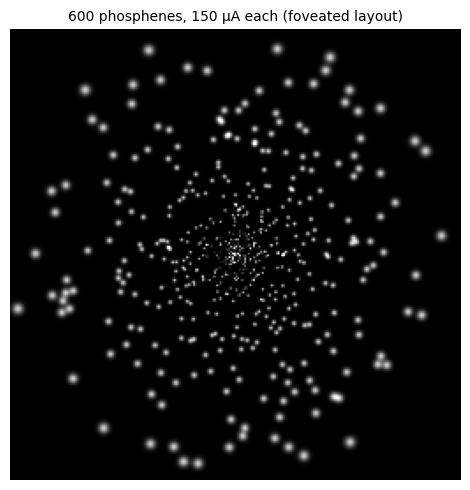

In [ ]:
# Render the whole population once — fire every electrode at the same current.
# 150 µA sits comfortably above the model's activation threshold for these
# params. (80 µA lands just *below* threshold here, so the thresholding step
# zeroes every phosphene and the image comes back completely black.)
# Build the amplitude vector on the simulator's own device/dtype (**sim.data_kwargs)
# so it also works when dynaphos is running on the GPU.
amp = torch.full((len(coords),), 150e-6, **sim.data_kwargs)   # 150 µA per electrode
sim.reset()
phosphenes = sim(amp).detach().cpu().numpy()
show(phosphenes, titles=[f'{len(coords)} phosphenes, 150 µA each (foveated layout)'],
     figsize=(5, 5))

The dynaphos library ships a probabilistic foveated sampler
(`get_visual_field_coordinates_probabilistically`) but no parameterised
uniform-grid sampler in the visual field. We build one ourselves with a
tiny helper that wraps the `Map` class.


In [ ]:
def make_uniform_visual_field(side: int, view_angle: float) -> Map:
    '''Side×side electrodes spaced evenly inside [-view_angle/2, +view_angle/2].'''
    hemi = view_angle / 2
    step = view_angle / side
    xs = np.linspace(-hemi + step/2, hemi - step/2, side)
    ys = np.linspace(-hemi + step/2, hemi - step/2, side)
    xx, yy = np.meshgrid(xs, ys)
    return Map(x=xx.ravel(), y=yy.ravel())


### Exercise 1.1 — animate the phosphene growing with eccentricity `[easy]`

A phosphene's size $\sigma$ (deg) grows with eccentricity at a fixed
current, following

$$\sigma(\text{deg}) \;=\; s\,\frac{\sqrt{I/K}}{M(r)},\qquad
  M(r)=\frac{k\,(b-a)}{(r+a)(r+b)}.$$

**Your job is the math and the loop; the drawing is done for you.** The
premade `animate_phosphene_growth(eccentricities, sigmas_deg)` helper (defined
in the cell just above) turns your computed sizes into a GIF of a single
phosphene swelling as the eccentricity climbs — you only have to produce the
`sigmas_deg` array.

1. Pick `I = 150e-6` A, `K = params['size']['current_spread']`, and
   `s = params['size']['radius_to_sigma']`; compute `radius_mm = np.sqrt(I/K)`
   (activated-cortex radius, Bosking et al.'s sqrt law).
2. Sweep eccentricity `r` from `0.5°` to `7.5°`. **Loop** over the values and,
   for each, get `M(r)` from
   `get_cortical_magnification(np.array([r]), params['cortex_model'])` and
   compute `sigma_deg = s * radius_mm / M(r)`.
3. Collect the σ values into an array and call
   `animate_phosphene_growth(eccentricities, sigmas_deg)`. Watch the phosphene
   swell from a tight foveal dot into a fat peripheral blob.

In [ ]:
# ── PREMADE VISUALISER (provided — you don't need to edit or understand this) ──
# Given matched arrays of eccentricities (deg) and phosphene sizes σ (deg), this
# animates a single 2-D Gaussian phosphene whose width tracks your σ values, and
# writes it to a GIF that plays inline. The view is auto-zoomed to the σ range
# (these phosphenes are a fraction of a degree wide) so the growth is visible.
# You supply the math; this does the drawing.
import matplotlib.animation as animation
from IPython.display import Image

def animate_phosphene_growth(eccentricities, sigmas_deg, fps=8,
                             save_path='assets/phosphene_growth.gif'):
    ecc = np.asarray(eccentricities, dtype=float)
    sig = np.asarray(sigmas_deg, dtype=float)
    half = 2.5 * float(sig.max())            # zoom the window to the largest phosphene
    res = 256
    grid = np.linspace(-half, half, res)
    xx, yy = np.meshgrid(grid, grid)

    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    im = ax.imshow(np.zeros((res, res)), cmap='gray', vmin=0, vmax=1,
                   extent=[-half, half, -half, half], origin='lower')
    ax.set_xlabel('degrees of visual angle'); ax.set_yticks([])
    title = ax.set_title('')

    def draw(i):
        s = sig[i]
        blob = np.exp(-((xx**2 + yy**2) / (2.0 * s**2)))   # Gaussian phosphene, peak 1
        im.set_data(blob)
        title.set_text(f'eccentricity r = {ecc[i]:4.1f}°     σ = {s:5.3f}°')
        return im, title

    anim = animation.FuncAnimation(fig, draw, frames=len(ecc),
                                   interval=1000.0 / fps, blit=False)
    plt.close(fig)                            # don't show the static frame
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    anim.save(save_path, writer=animation.PillowWriter(fps=fps))
    print(f'saved {save_path}  ({len(ecc)} frames, σ {sig.min():.3f}°→{sig.max():.3f}°)')
    return Image(filename=save_path)          # plays inline in the notebook

saved assets/phosphene_growth.gif  (40 frames, σ 0.017°→0.120°)


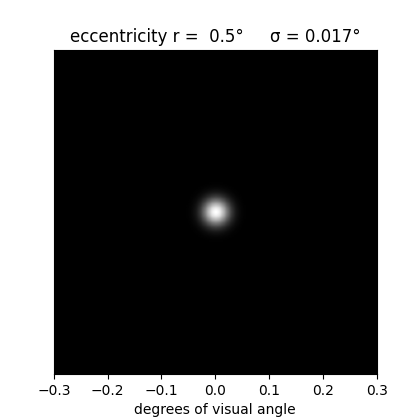

In [ ]:
# The math is yours; the animation is premade.
I_amp = 150e-6
K = params['size']['current_spread']
s = params['size']['radius_to_sigma']
radius_mm = np.sqrt(I_amp / K)            # activated-cortex radius (Bosking sqrt law)

# Loop over eccentricity and apply the size relation σ_deg = s · radius_mm / M(r).
eccentricities = np.linspace(0.5, 7.5, 40)
sigmas_deg = np.empty_like(eccentricities)
for i, r in enumerate(eccentricities):
    M_r = float(get_cortical_magnification(np.array([r]), params['cortex_model'])[0])
    sigmas_deg[i] = s * radius_mm / M_r

# Hand the computed sizes to the premade visualiser → growing-phosphene GIF.
animate_phosphene_growth(eccentricities, sigmas_deg)

### Exercise 1.2 — foveated vs uniform electrode layout `[intermediate]`

With the same N electrodes, two layout strategies give very different
percepts. Build them both and render the max-projection basis map for each.

1. Build a foveated population with `get_visual_field_coordinates_probabilistically(params, N, rng=rng)`.
2. Build a uniform population with `get_visual_field_coordinates_grid(params, N_x, N_y, view_angle)`.
   (`N_x = N_y ≈ sqrt(N)` so the total matches.)
3. Wrap each in a `GaussianSimulator(params, coords)`.
4. Fire every electrode at 150 µA and render. Plot side-by-side.
5. Look at the centre vs the edge — which layout gives finer central
   detail, which finer peripheral detail?

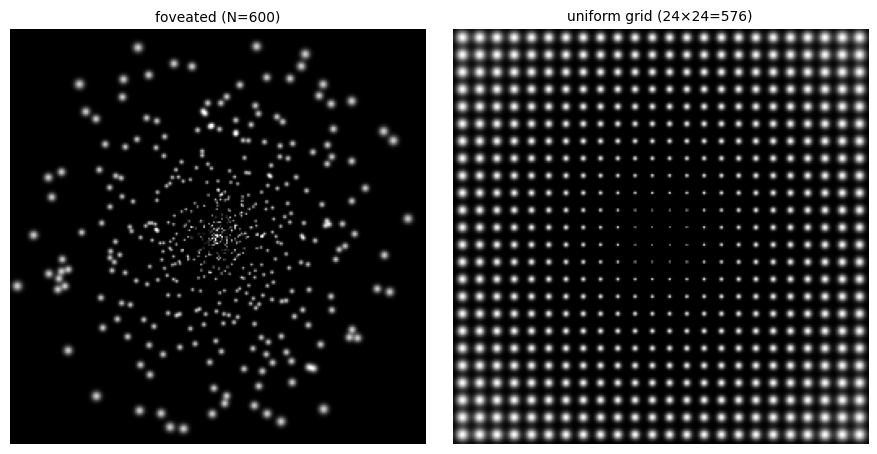

In [ ]:
N = 600
side = int(round(np.sqrt(N)))   # 24×24 ≈ 576, close enough to 600

rng = np.random.default_rng(params['run']['seed'])
coords_fov = get_visual_field_coordinates_probabilistically(params, N, rng=rng)
coords_uni = make_uniform_visual_field(side, params['run']['view_angle'])

sim_fov = GaussianSimulator(params, coords_fov)
sim_uni = GaussianSimulator(params, coords_uni)

# 150 µA — above threshold (see above); build each amp on its simulator's device.
amp_fov = torch.full((len(coords_fov),), 150e-6, **sim_fov.data_kwargs)
amp_uni = torch.full((len(coords_uni),), 150e-6, **sim_uni.data_kwargs)

sim_fov.reset(); sim_uni.reset()
ph_fov = sim_fov(amp_fov).detach().cpu().numpy()
ph_uni = sim_uni(amp_uni).detach().cpu().numpy()

show(ph_fov, ph_uni,
     titles=[f'foveated (N={len(coords_fov)})',
             f'uniform grid ({side}×{side}={len(coords_uni)})'],
     cols=2, figsize=(9, 4.5))

## 2 · Image → phosphenes (forward pass)

This is the engineer's job: turn an image into a set of stimulation
amplitudes, one per electrode. The simulator's `sample_stimulus(image)`
does this by sampling the image intensity at each electrode's receptive
field. Then `simulator(amplitudes)` runs the physics and renders the
phosphene image.

The signature you'll use over and over:

```python
amplitudes = simulator.sample_stimulus(image, rescale=True)   # (N_electrodes,)
phosphenes = simulator(amplitudes)                            # (H, W), in [0, 1]
```

Input `image` is a `(H, W)` uint8 or float array at the resolution
declared in the params file (256×256 here). `rescale=True` maps the
image's [0, max] range to a reasonable stim amplitude band.


firing threshold ≈ 86.6 µA · stim_floor(gain=3) = 74 / 255


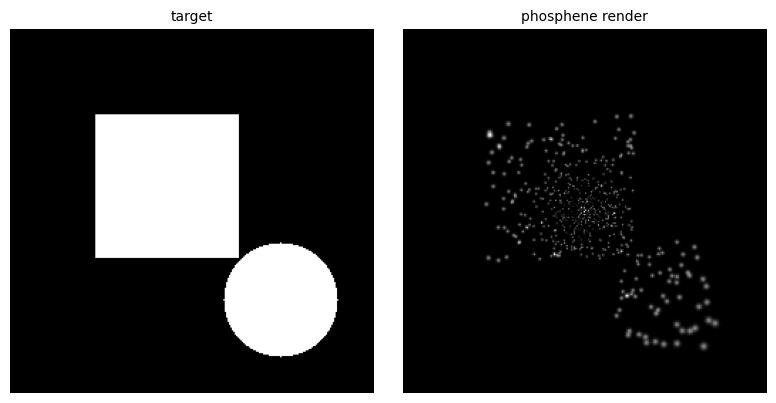

In [ ]:
RES = tuple(params['run']['resolution'])   # (W, H) — 256, 256

def draw_pattern(name: str) -> np.ndarray:
    '''Return a 256×256 grayscale uint8 image for one of the abstract presets.'''
    img = np.zeros(RES[::-1], dtype=np.uint8)
    h, w = img.shape
    if name == 'square_disc':
        cv2.rectangle(img, (60, 60), (160, 160), 255, -1)
        cv2.circle(img, (190, 190), 40, 255, -1)
    elif name == 'letter_E':
        cv2.putText(img, 'E', (40, 210), cv2.FONT_HERSHEY_SIMPLEX, 8.0, 255, 18, cv2.LINE_AA)
    elif name == 'grating':
        for x in range(0, w, 16):
            cv2.rectangle(img, (x, 0), (x+8, h), 255, -1)
    elif name == 'diagonal':
        cv2.line(img, (20, 20), (w-20, h-20), 255, 6, cv2.LINE_AA)
    else:
        raise ValueError(name)
    return img

# Rebuild a fresh simulator that we'll use for §2-§4. Foveated, 1000 electrodes
# so the abstract shapes have something to bind to.
N = 1000
coords = get_visual_field_coordinates_probabilistically(params, N, rng=np.random.default_rng(0))
sim = GaussianSimulator(params, coords)

# --- stimulation helpers ---------------------------------------------------
# The simulator only lights a phosphene once an electrode's amplitude clears a
# firing threshold. From the params that amplitude is, for a single one-shot
# render (one forward pass from reset):
#     amp_thresh = rheobase + activation_threshold * fps / (pw * freq * stim_dur)
# Below it, nothing appears. Two consequences we handle throughout §2-§4:
#   * a raw, low-contrast photo barely reaches it -> scale amplitudes up (gain);
#   * a graded activation map naively normalised to [0, 255] leaves its low and
#     mid values *below* threshold, so only its brightest pixels fire -> instead
#     normalise its foreground to [floor, 255], where `floor` is the smallest
#     level that still fires (the "x" in an x..255 normalisation).
STIM_GAIN = 3.0   # multiplies sampled amplitudes; widens the supra-threshold band

def amp_threshold() -> float:
    '''Smallest electrode amplitude (A) that fires a phosphene in a one-shot render.'''
    t, d = params['thresholding'], params['default_stim']
    return t['rheobase'] + t['activation_threshold'] * params['run']['fps'] / (
        d['pw_default'] * d['freq_default'] * d['relative_stim_duration'])

def stim_floor(gain: float = STIM_GAIN) -> int:
    '''Smallest 0-255 level whose sampled amplitude clears the firing threshold
    at this gain — the "x" in an x..255 normalisation.'''
    return int(np.ceil(255 * amp_threshold() / (params['sampling']['stimulus_scale'] * gain)))

def stim_normalize(mask: np.ndarray, gain: float = STIM_GAIN) -> np.ndarray:
    '''Linearly map a mask/activation map's *nonzero* foreground into
    [stim_floor, 255] instead of [0, 255], so even its dimmest selected region
    still drives a phosphene while preserving the relative ordering. Pixels that
    are exactly 0 are background and stay off. Binary masks (foreground already
    all 255) come back unchanged.'''
    m = np.asarray(mask, np.float32)
    out = np.zeros_like(m)
    fg = m > 0
    if fg.any():
        lo, hi = float(m[fg].min()), float(m[fg].max())
        floor = stim_floor(gain)
        out[fg] = 255.0 if hi == lo else floor + (m[fg] - lo) * (255.0 - floor) / (hi - lo)
    return out.astype(np.uint8)

def render(image_uint8: np.ndarray, gain: float = 1.0) -> np.ndarray:
    '''image_uint8 -> phosphene render (H, W) float in [0, 1].

    `gain` multiplies the sampled stimulation amplitudes. With rescale=True the
    image's [0,255] range maps to [0, stimulus_scale] = [0, 100 µA], but the
    model only fires phosphenes above ~87 µA — so at gain=1 a low-contrast input
    barely lights up. Bump `gain` (and/or pre-process with `stim_normalize`) to
    push the dynamic range above threshold.'''
    sim.reset()
    amp = sim.sample_stimulus(image_uint8, rescale=True) * gain
    return sim(amp).detach().cpu().numpy()

print(f'firing threshold ≈ {amp_threshold()*1e6:.1f} µA · '
      f'stim_floor(gain={STIM_GAIN:g}) = {stim_floor()} / 255')
target = draw_pattern('square_disc')
show(target, render(target), titles=['target', 'phosphene render'], cols=2, figsize=(8, 4))

### Exercise 2.1 — abstract patterns survive coarse sampling `[easy]`

Loop over the four preset patterns and render each through the
simulator. Display a 2×4 grid: top row = targets, bottom row = phosphene
renders. Which ones stay recognisable, which fall apart?

> Hint: the patterns are `['square_disc', 'letter_E', 'grating', 'diagonal']`.
> Build two lists (`targets`, `renders`) and call
> `show(*(targets + renders), titles=..., cols=4)`.


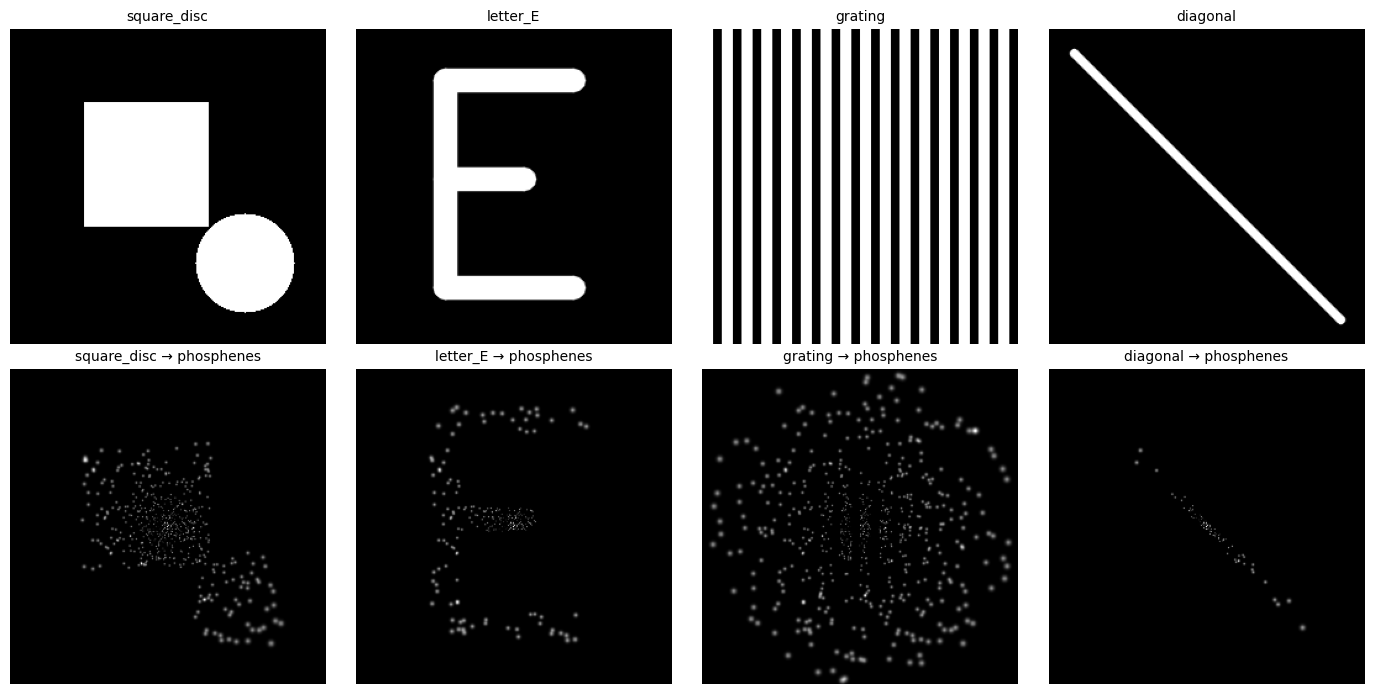

In [ ]:
names = ['square_disc', 'letter_E', 'grating', 'diagonal']
targets = [draw_pattern(n) for n in names]
renders = [render(t) for t in targets]
show(*(targets + renders),
     titles=names + [f'{n} → phosphenes' for n in names],
     cols=4, figsize=(14, 7))


### Exercise 2.2 — natural photos: blobs, then edges `[intermediate]`

Now try a real photo. First push the portrait through the simulator
raw (just resized to 256×256, grayscale). You should get a featureless
bright blob — the silhouette of the head. Then preprocess with
`cv2.Canny` first, and pass the edge map through the same simulator.

1. Load `PORTRAIT` with `cv2.imread(str(PORTRAIT), cv2.IMREAD_GRAYSCALE)`. If
   the image is missing, fall back to a synthetic blob:
   `face = np.zeros(RES[::-1], np.uint8); cv2.ellipse(face, (128,128), (60,80), 0, 0, 360, 255, -1)`.
2. Resize to `RES`, render. Plot input + render.
3. `edges = cv2.Canny(cv2.GaussianBlur(face, (5,5), 1.4), 50, 150)`. Render
   the edges instead. Plot input + edges + edge-render.
4. Which carries more facial information through the prosthesis — the
   raw intensity or the edges?

> **Why `gain=3`?** A photo's mid-grey tones map (via `rescale=True`) to
> currents *below* the model's ~88 µA firing threshold, so at the default
> gain only a few bright highlights would light up. We scale the stimulus
> up so most of the foreground clears threshold and you actually see the
> blob — and we use the *same* gain for the edge map so the only thing
> that differs between the two panels is the preprocessing, not the drive
> current.

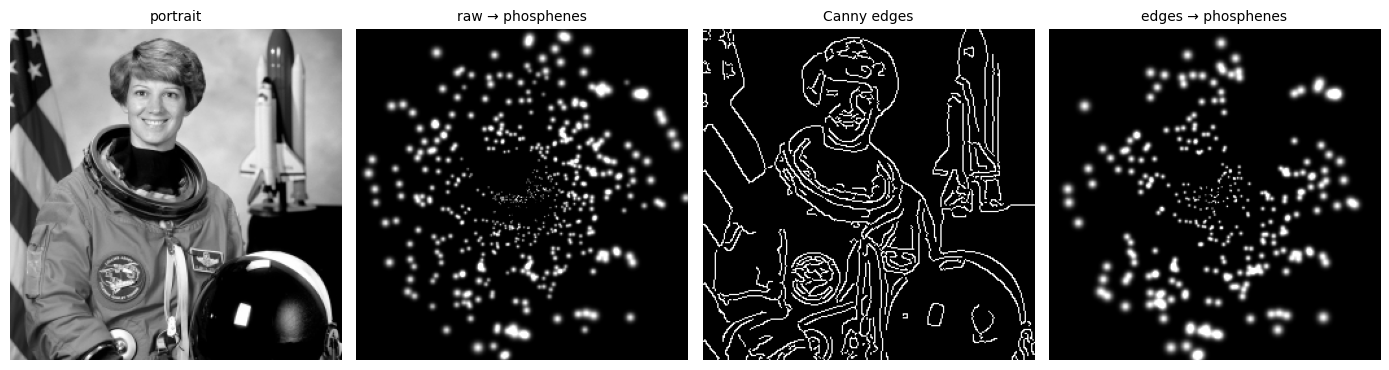

In [ ]:
face = cv2.imread(str(PORTRAIT), cv2.IMREAD_GRAYSCALE)
if face is None:
    face = np.zeros(RES[::-1], np.uint8)
    cv2.ellipse(face, (128, 128), (60, 80), 0, 0, 360, 255, -1)
face = cv2.resize(face, RES)

# A natural photo's mid-tones map to amplitudes below the firing threshold, so
# at the default gain only a handful of bright highlights light up — not the
# head-shaped blob we're after. Drive the stimulus at STIM_GAIN so most of the
# foreground clears threshold, and use the SAME gain for the edge map so the
# raw-vs-edges comparison differs only in preprocessing, not in drive current.
raw_render = render(face, gain=STIM_GAIN)
edges = cv2.Canny(cv2.GaussianBlur(face, (5, 5), 1.4), 50, 150)
edge_render = render(edges, gain=STIM_GAIN)

show(face, raw_render, edges, edge_render,
     titles=['portrait', 'raw → phosphenes', 'Canny edges', 'edges → phosphenes'],
     cols=4, figsize=(14, 4))

## 3 · Temporal dynamics — phosphenes fade under steady stimulation

Everything so far was a single snapshot: stimulus in, one phosphene image out.
But dynaphos carries an internal **adaptation state** (a "trace" $B$): while an
electrode is driven, $B$ climbs and adds to the leak current, so the *effective*
current — and the phosphene's brightness — slowly **fades**, even though the
stimulation never changes. (When the drive stops, $B$ decays and the cell
recovers.) This is the model's version of the perceptual fading that real
implant users report during prolonged steady stimulation.

We won't poke sliders like the companion HTML page does — we just *watch* the
effect. The key is that the simulator is **stateful**: as long as you keep
calling it **without** `sim.reset()`, the trace carries over from frame to
frame. So we hold a stimulus fixed and animate the phosphene field as a GIF; the
brightness curve beside it quantifies the fade.

The premade `animate_stimulation(...)` below does all the stepping and drawing —
you only build the stimulus.

In [ ]:
# A dedicated simulator for §3. A uniform grid keeps the raster timing-groups in
# the 3.3 challenge clean to define, and is dense enough that neighbouring
# phosphenes overlap — exactly the merging that raster scanning has to fight.
GRID_SIDE = 18
coords3 = make_uniform_visual_field(GRID_SIDE, params['run']['view_angle'])
sim3 = GaussianSimulator(params, coords3)
print(f'sim3: {sim3.num_phosphenes} electrodes on a {GRID_SIDE}x{GRID_SIDE} grid')

# ── PREMADE VISUALISER (provided — you don't need to edit this) ───────────────
import matplotlib.animation as animation
from IPython.display import Image, display

def animate_stimulation(sim, amps_per_frame, n_frames=70, fps=12,
                        title='', save_path='assets/stim_fade.gif'):
    '''Step the STATEFUL simulator (one reset at the start, none after) so the
    adaptation trace carries from frame to frame, and render a GIF: left = the
    phosphene field, right = mean brightness vs time. `amps_per_frame` is either
    a single (n_electrodes,) vector — held every frame — or a (T, n_electrodes)
    array giving a different vector per frame (used by the raster challenge).
    Accepts numpy or torch; you build the stimulus, this does the drawing.'''
    if hasattr(amps_per_frame, 'detach'):
        amps_per_frame = amps_per_frame.detach().cpu().numpy()
    A = np.asarray(amps_per_frame, dtype=np.float32)
    if A.ndim == 1:
        A = np.tile(A, (n_frames, 1))               # hold the same stimulus each frame
    T = A.shape[0]

    sim.reset()                                      # the ONLY reset — state then carries over
    frames, bright = [], []
    for t in range(T):
        amp = torch.as_tensor(A[t], **sim.data_kwargs)
        phos = sim(amp).detach().cpu().numpy()
        frames.append(phos); bright.append(float(phos.mean()))
    bright = np.asarray(bright); ts = np.arange(T) / params['run']['fps']

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(8.6, 4.0),
                                   gridspec_kw={'width_ratios': [1, 1.15]})
    imL = axL.imshow(frames[0], cmap='gray', vmin=0, vmax=1)
    axL.set_xticks([]); axL.set_yticks([]); axL.set_title(title or 'phosphene field')
    axR.set_xlim(0, ts[-1] if ts[-1] > 0 else 1)
    axR.set_ylim(0, float(bright.max()) * 1.15 + 1e-6)
    axR.set_xlabel('time (s)'); axR.set_ylabel('mean brightness'); axR.set_title('brightness over time')
    (line,) = axR.plot([], [], color='C0'); (dot,) = axR.plot([], [], 'o', color='C1')

    def draw(t):
        imL.set_data(frames[t])
        line.set_data(ts[:t + 1], bright[:t + 1]); dot.set_data([ts[t]], [bright[t]])
        return imL, line, dot

    anim = animation.FuncAnimation(fig, draw, frames=T, interval=1000.0 / fps, blit=False)
    plt.close(fig)
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    anim.save(save_path, writer=animation.PillowWriter(fps=fps))
    print(f'saved {save_path}  ({T} frames; peak {bright.max():.3f} -> end {bright[-1]:.3f})')
    return Image(filename=save_path)

sim3: 324 electrodes on a 18x18 grid


### Exercise 3.1 — watch a steady stimulus fade `[easy]`

Fire **every** electrode at one fixed current and hold it. Because the simulator
is stateful, the adaptation trace builds up over the next second or so and the
whole field visibly dims — no parameter tweaking required.

We use a **modest current (~100 µA, just above threshold)** here, *not* the
150 µA from §1. The fade is a reduction in the *effective* current as the trace
grows; near threshold that swings brightness a lot, but at the high, **saturated**
currents §1/§2 used for visibility the brightness barely moves and the effect
hides. So §3 trades peak brightness for a visible fade.

1. Build an all-active amplitude vector: every electrode at `100e-6` A
   (`np.full(sim3.num_phosphenes, 100e-6)` — the helper moves it to the device).
2. `animate_stimulation(sim3, amp_all, title='all electrodes · 100 µA held')`.
3. Watch the GIF dim, and the brightness curve sag from its early peak — that
   sag is the adaptation trace, straight out of dynaphos.

saved assets/fade_all_active.gif  (70 frames; peak 0.058 -> end 0.031)


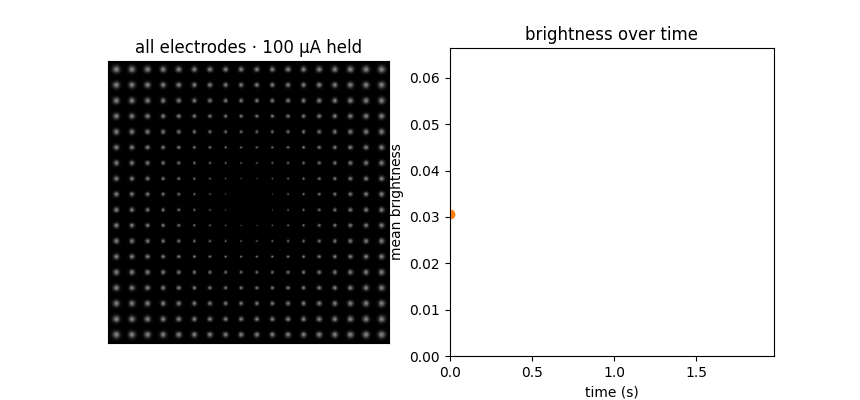

In [ ]:
# Every electrode on at a near-threshold current, held for the whole clip.
amp_all = np.full(sim3.num_phosphenes, 100e-6, dtype=np.float32)
animate_stimulation(sim3, amp_all, n_frames=70,
                    title='all electrodes · 100 µA held',
                    save_path='assets/fade_all_active.gif')

### Exercise 3.2 — fade a real (edge) image `[intermediate]`

A flat all-on field is the easy case. Now hold a *structured* stimulus and watch
the same adaptation hollow it out. Use the **edge map** of a photo (edges are
the most prosthesis-legible representation, as §2.2 showed) as the held stimulus.

1. Edge-detect a photo — reuse `face` from §2.2:
   `edges = cv2.Canny(cv2.GaussianBlur(face, (5, 5), 1.4), 50, 150)`.
2. Sample it to per-electrode amplitudes for `sim3`:
   `amp_edges = sim3.sample_stimulus(edges, rescale=True)`. (Edge pixels are
   already 255, so `rescale=True` lands them right around 100 µA — the same
   near-threshold band as 3.1, no extra gain needed. Bumping it with `STIM_GAIN`
   would *saturate* the phosphenes and the fade would vanish — try it and see.)
3. `animate_stimulation(sim3, amp_edges, title='edge map held')` and watch the
   edge phosphenes dim over the clip — the same trace, now riding on structure.

saved assets/fade_edges.gif  (70 frames; peak 0.027 -> end 0.014)


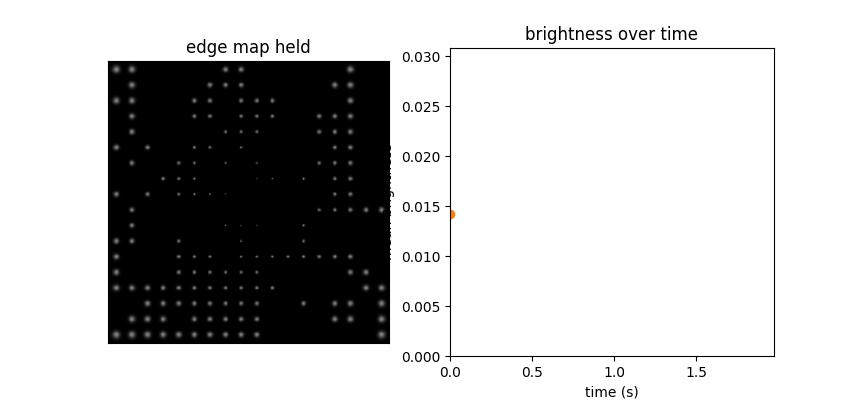

In [ ]:
# Hold the edge map of the §2.2 face and watch it fade. No STIM_GAIN here —
# edge pixels already sample to ~100 µA, the near-threshold band where the fade
# is visible (gain would saturate it).
edges = cv2.Canny(cv2.GaussianBlur(face, (5, 5), 1.4), 50, 150)
amp_edges = sim3.sample_stimulus(edges, rescale=True)
animate_stimulation(sim3, amp_edges, n_frames=70,
                    title='edge map held',
                    save_path='assets/fade_edges.gif')

### Exercise 3.3 — raster scanning `[challenge]`

Real implants can't safely fire every electrode at once (charge limits), and
simultaneously-active **neighbours merge** into blobs that wreck legibility.
**Raster scanning** (Beyeler et al., 2025 — [arXiv:2501.02084](https://arxiv.org/abs/2501.02084))
fixes both: split the array into a few *timing groups* and fire **one group per
frame**; persistence of vision stitches the groups back into a single percept.

The *spatial layout* of the groups matters. A **checkerboard** maximises the
distance between simultaneously-active electrodes, so phosphenes merge far less
and shapes stay sharp — it beat horizontal / vertical / random rasters on letter
and motion tasks in their study. Implement raster scanning over `sim3` and
compare a **checkerboard** raster to a **horizontal** one on the same stimulus.

1. Build a per-electrode **target** amplitude from a stimulus, e.g.
   `target = sim3.sample_stimulus(draw_pattern('letter_E'), rescale=True) * STIM_GAIN`.
2. Assign each electrode to one of `G` timing groups. `sim3` is a
   `GRID_SIDE×GRID_SIDE` grid raveled row-major, so for electrode index `i`:
   `row, col = i // GRID_SIDE, i % GRID_SIDE`. Then
   **checkerboard** = `(col + row) % G` (every 4-neighbour lands in a *different*
   group), **horizontal** = `row % G` (whole rows fire together).
3. Make a `(T, n_electrodes)` array: at frame `t`, only electrodes whose
   `group == t % G` carry their `target`; the rest are 0. Run a few cycles
   (`T = G * cycles`).
4. `animate_stimulation(sim3, amps, ...)` for each pattern. The checkerboard's
   simultaneously-lit phosphenes stay spread out (less merging); the horizontal
   raster lights whole rows at once, which clump into bars.

saved assets/raster_checker.gif  (24 frames; peak 0.006 -> end 0.005)


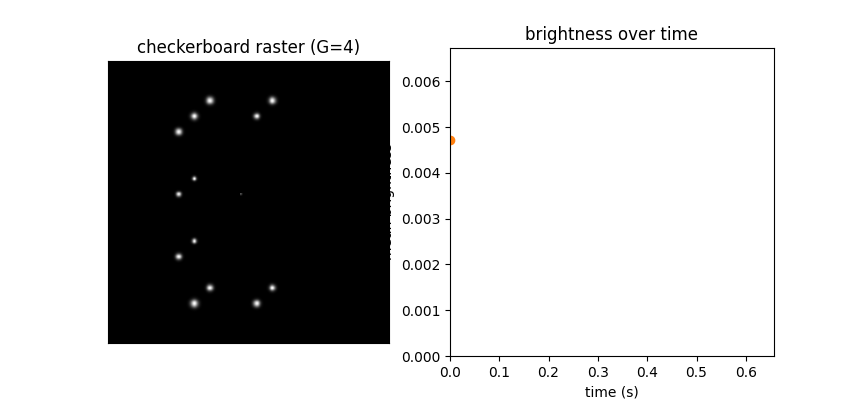

saved assets/raster_horizontal.gif  (24 frames; peak 0.009 -> end 0.009)


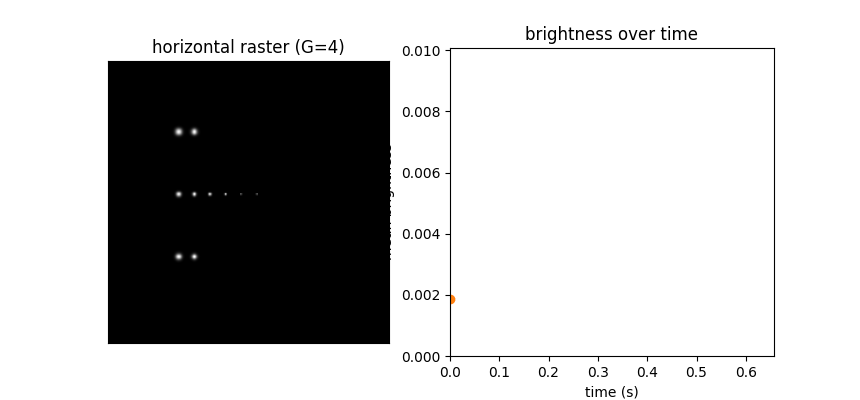

In [ ]:
# Per-electrode target amplitude from a letter 'E' (bright, so the raster groups
# read clearly; the fade isn't the point here — the spatial merging is).
target = (sim3.sample_stimulus(draw_pattern('letter_E'), rescale=True)
          * STIM_GAIN).detach().cpu().numpy()

# sim3 is a GRID_SIDE×GRID_SIDE grid raveled row-major, so the row/col of each
# electrode come straight from its index.
idx = np.arange(sim3.num_phosphenes)
row, col = idx // GRID_SIDE, idx % GRID_SIDE

G, CYCLES = 4, 6                       # 4 timing groups, 6 scan cycles
def raster_amps(group_of_electrode):
    '''(T, n_electrodes): each frame, only the active group carries `target`.'''
    T = G * CYCLES
    A = np.zeros((T, sim3.num_phosphenes), dtype=np.float32)
    for t in range(T):
        active = group_of_electrode == (t % G)
        A[t, active] = target[active]
    return A

checker = (col + row) % G              # neighbours fall in different groups → spread out
horizontal = row % G                   # whole rows fire together → clump into bars

display(animate_stimulation(sim3, raster_amps(checker), fps=8,
                            title=f'checkerboard raster (G={G})',
                            save_path='assets/raster_checker.gif'))
display(animate_stimulation(sim3, raster_amps(horizontal), fps=8,
                            title=f'horizontal raster (G={G})',
                            save_path='assets/raster_horizontal.gif'))

## 4 · AI-driven stimulus

Up to here, the stimulus was either an abstract shape or a raw photo
intensity sampled at each electrode. Real prostheses don't have to work
that way — the input to `sim.sample_stimulus(...)` can be **anything**
you can compute from the camera. This section drives the same simulator
from the outputs of four computer-vision models and compares the resulting
phosphene renders.

* **4.1** YOLOv8n-seg — class-weighted object masks
* **4.2** MiDaS — monocular depth, near = bright
* **4.3** DeepGaze IIE — free-viewing saliency, "where the user would look"
* **4.4** YOLO-World — open-vocabulary detection from a free-text class list

We run all of them on `bus.jpg` (the M1 image) so the renders are
visually comparable.

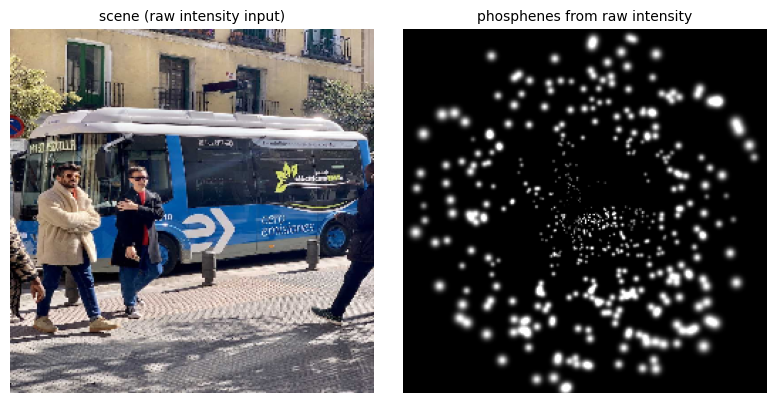

In [ ]:
# Load and resize bus.jpg to the simulator's resolution.
bgr = cv2.imread(str(BUS))
scene_gray = cv2.resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), RES)
scene_bgr  = cv2.resize(bgr, RES)
# Raw intensity is a natural photo, so (like §2.2) drive it at STIM_GAIN —
# otherwise its mid-tones stay below threshold and the panel is nearly empty.
show(scene_bgr, render(scene_gray, gain=STIM_GAIN),
     titles=['scene (raw intensity input)', 'phosphenes from raw intensity'],
     cols=2, figsize=(8, 4))

### YOLO segmentation → phosphenes

YOLOv8n-seg returns one binary mask per detection. We collapse them into
a single "objects vs background" activation map and feed *that* in
instead of raw pixels. Things that aren't objects (sky, pavement) go
dark; people, vehicles, etc. light up.


YOLO ran on cuda. 6 detections.


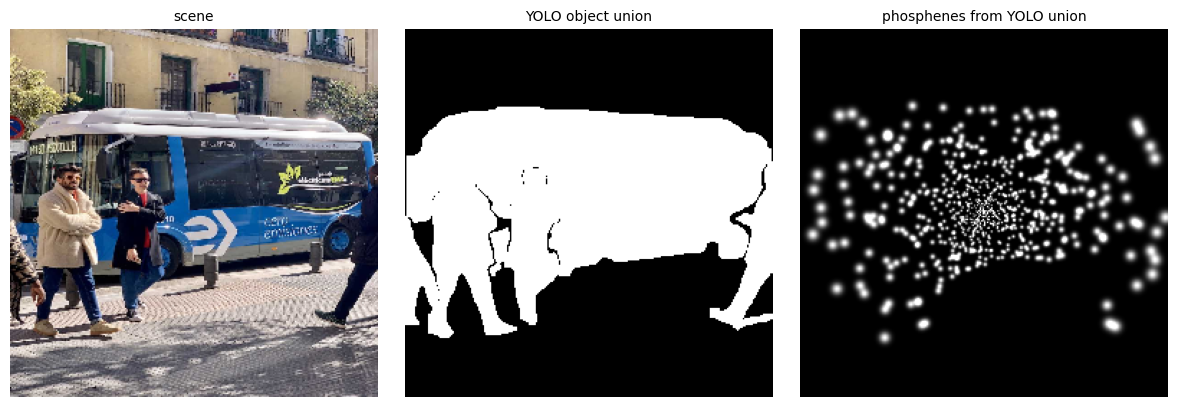

In [ ]:
yolo_ok = False
try:
    from ultralytics import YOLO
    yolo_model = YOLO('yolov8n-seg.pt')
    yolo_res = yolo_model.predict(str(BUS), device=DEVICE, verbose=False)[0]
    yolo_ok = True
    print(f'YOLO ran on {DEVICE}. {len(yolo_res.boxes)} detections.')
except Exception as e:
    print('YOLO unavailable, will fall back to brightness threshold:', e)

def get_yolo_masks_resized(out_shape):
    '''Return (masks (N,H,W) uint8, class_ids (N,), names dict).'''
    if not yolo_ok:
        # Fallback: split bright-vs-dim regions of the scene as a 1-class "mask"
        m = (scene_gray > 110).astype(np.uint8)
        return m[None, :, :], np.array([0]), {0: 'bright'}
    raw = yolo_res.masks.data.cpu().numpy()
    H, W = out_shape
    masks = np.stack([
        (cv2.resize(m, (W, H), interpolation=cv2.INTER_LINEAR) > 0.5).astype(np.uint8)
        for m in raw
    ])
    cls = yolo_res.boxes.cls.cpu().numpy().astype(int)
    return masks, cls, yolo_res.names

masks, cls, names = get_yolo_masks_resized(RES[::-1])
union = (np.any(masks.astype(bool), axis=0).astype(np.uint8) * 255)
# stim_normalize keeps this binary mask as-is (foreground already 255); we drive
# it at STIM_GAIN so the object regions read as solid, bright phosphenes.
show(scene_bgr, union, render(stim_normalize(union), gain=STIM_GAIN),
     titles=['scene', 'YOLO object union', 'phosphenes from YOLO union'],
     cols=3, figsize=(12, 4))

### Exercise 4.1 — class-weighted activation `[easy]`

Not every class is equally informative for a prosthesis user. Build a
single `(H, W)` float map where each pixel takes the **largest** weight
of any object covering it, using
`weights = {'person': 1.0, 'bus': 0.5, 'skateboard': 0.2}`. People should
be the brightest blobs in the resulting phosphene render.

Variables already in scope: `masks` `(N, H, W)`, `cls` `(N,)`,
`names` `dict[int,str]`.

> **Normalise to `[floor, 255]`, not `[0, 255]`.** If you just do
> `weight * 255`, the weights 0.2 and 0.5 map to 51 and 127 — both *below*
> the ~87 µA firing threshold — so only `person` would light up. Pass the
> map through `stim_normalize(...)` (defined in §2): it remaps the nonzero
> foreground to `[stim_floor(), 255]` so every weighted class clears
> threshold while keeping the 0.2 / 0.5 / 1.0 ordering as dim / mid /
> bright phosphenes.

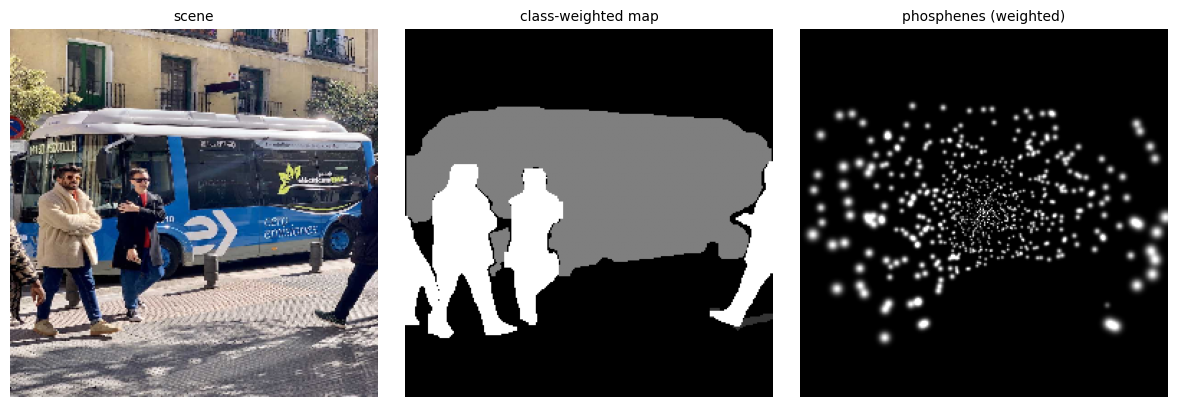

In [ ]:
weights = {'person': 1.0, 'bus': 0.5, 'skateboard': 0.2}
canvas = np.zeros(RES[::-1], dtype=np.float32)
for m, c in zip(masks, cls):
    w = weights.get(names[int(c)], 0.0)
    if w > 0:
        canvas = np.maximum(canvas, w * m.astype(np.float32))
weighted = (canvas * 255).astype(np.uint8)

# Naively, weight 0.2 -> 51 and 0.5 -> 127, both *below* the firing threshold,
# so only `person` (1.0 -> 255) would show. stim_normalize remaps the nonzero
# foreground to [floor, 255], so every weighted class clears threshold and the
# 0.2 / 0.5 / 1.0 ordering survives as dim / mid / bright phosphenes.
show(scene_bgr, weighted, render(stim_normalize(weighted), gain=STIM_GAIN),
     titles=['scene', 'class-weighted map', 'phosphenes (weighted)'],
     cols=3, figsize=(12, 4))

### Exercise 4.2 — monocular depth → phosphenes `[intermediate]`

A prosthesis built for **navigation** cares about *what's close*, not
*what's bright*. Use the MiDaS small monocular-depth model to estimate
relative depth, then make a "near = bright" activation map.

1. Load MiDaS via `torch.hub`:
   `midas = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small').to(DEVICE).eval()`
2. Get its preprocessing transform:
   `transform = torch.hub.load('intel-isl/MiDaS', 'transforms').small_transform`
3. Run on `cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)`, getting a `(H, W)`
   depth map. (MiDaS returns inverse depth: larger = closer.)
4. Normalise to `[0, 255]` uint8 (already near = bright since it's inverse
   depth), resize to `RES`, render.
5. Display the depth map alongside its phosphene render.

If MiDaS isn't available, fall back to `cv2.applyColorMap`-free
brightness inversion as a stand-in (`(255 - scene_gray)`).


Using cache found in C:\Users\paple/.cache\torch\hub\intel-isl_MiDaS_master


C:\Users\paple\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:  None


Using cache found in C:\Users\paple/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


Using cache found in C:\Users\paple/.cache\torch\hub\intel-isl_MiDaS_master


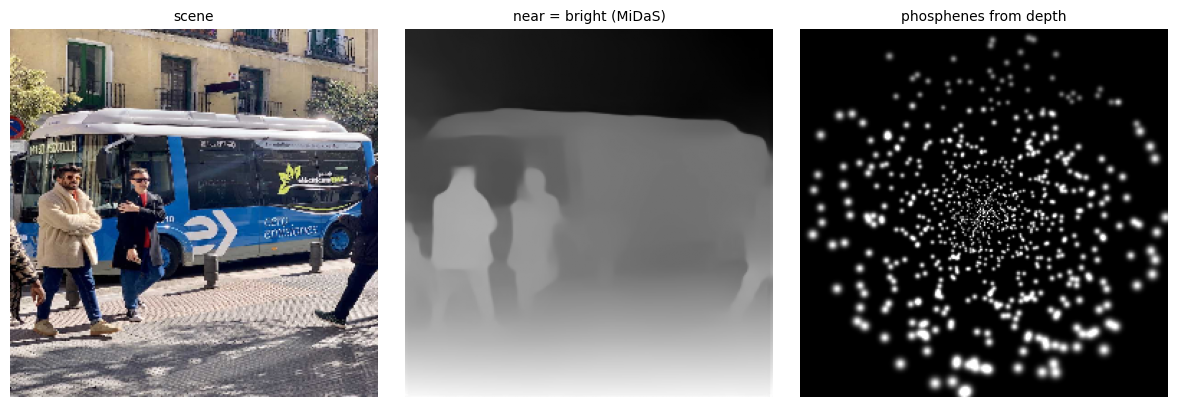

In [ ]:
depth_ok = False

# MiDaS_small pulls in two torch.hub repos: MiDaS itself, plus its
# efficientnet_lite3 backbone (rwightman/gen-efficientnet-pytorch). The
# nested backbone load isn't on torch's trusted list, so it would stop and
# ask "trust this repo? (y/N)" — which hangs a headless "Run All". We add
# both to the trusted list up front so the loads run unattended.
import torch.hub, pathlib
_trust = pathlib.Path(torch.hub.get_dir()) / 'trusted_list'
_trust.parent.mkdir(parents=True, exist_ok=True)
_have = _trust.read_text().split() if _trust.exists() else []
for _repo in ('intel-isl_MiDaS', 'rwightman_gen-efficientnet-pytorch'):
    if _repo not in _have:
        with open(_trust, 'a') as _f:
            _f.write(_repo + '\n')

try:
    midas = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small', trust_repo=True).to(DEVICE).eval()
    transforms = torch.hub.load('intel-isl/MiDaS', 'transforms', trust_repo=True)
    transform = transforms.small_transform
    rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)
    inp = transform(rgb).to(DEVICE)
    with torch.no_grad():
        pred = midas(inp)
        pred = torch.nn.functional.interpolate(
            pred.unsqueeze(1), size=RES[::-1], mode='bicubic', align_corners=False
        ).squeeze().cpu().numpy()
    depth = pred
    depth_ok = True
except Exception as e:
    print('MiDaS unavailable, falling back to brightness inversion:', e)
    depth = (255.0 - scene_gray).astype(np.float32)

depth_u8 = ((depth - depth.min()) / (np.ptp(depth) + 1e-9) * 255).astype(np.uint8)
# A naive [0,255] depth map leaves everything but the very nearest surface below
# threshold. stim_normalize maps the depth gradient into [floor, 255], so the
# whole near->far ramp shows as bright->dim phosphenes (near still brightest).
show(scene_bgr, depth_u8, render(stim_normalize(depth_u8), gain=STIM_GAIN),
     titles=['scene', 'near = bright (MiDaS)' if depth_ok else 'near = bright (fallback)',
             'phosphenes from depth'], cols=3, figsize=(12, 4))

### Exercise 4.3 — saliency-gated edges → phosphenes (DeepGaze) `[intermediate]`

§2.2 showed edges are the most legible representation, but a full edge map floods
the tiny phosphene budget with clutter. A free-viewing **saliency** model says
*which* edges are worth the electrodes. We use **DeepGaze IIE** (Linardos et al.,
2021 — same family as the M-gaze module) to predict where a sighted viewer would
look, then use that map to **gate the edges**: keep (and brighten) edges in
salient regions, dim and drop edges the viewer would ignore.

1. Load it: `deepgaze_pytorch.DeepGazeIIE(pretrained=True).to(DEVICE).eval()`.
   (First run downloads a backbone ensemble; it's large, so we free it again
   afterwards and fall back to CPU if the 4 GB GPU is tight.) Run it on the RGB
   scene with a center-bias prior and take the `(H, W)` **log-density**; min-max
   to a `[0, 1]` saliency weight.
2. `edges = cv2.Canny(...)` on the scene, then **weight each edge pixel by the
   local saliency**: `edge_saliency = (edges>0) * sal`. Salient edges stay near
   1, ignored edges drop toward 0.
3. Render at `gain=STIM_GAIN` **without** `stim_normalize`: the firing threshold
   does the filtering — low-saliency edges fall below it and vanish, salient
   edges fire with saliency-graded brightness.
4. Compare to the YOLO / depth renders: this spends the electrode budget on the
   structure a viewer would actually fixate.

C:\Users\paple\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\paple\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded pretrained weights for efficientnet-b5


Using cache found in C:\Users\paple/.cache\torch\hub\pytorch_vision_v0.6.0
C:\Users\paple\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet201_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet201_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using cache found in C:\Users\paple/.cache\torch\hub\pytorch_vision_v0.6.0
C:\Users\paple\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DeepGaze IIE ran on cuda.


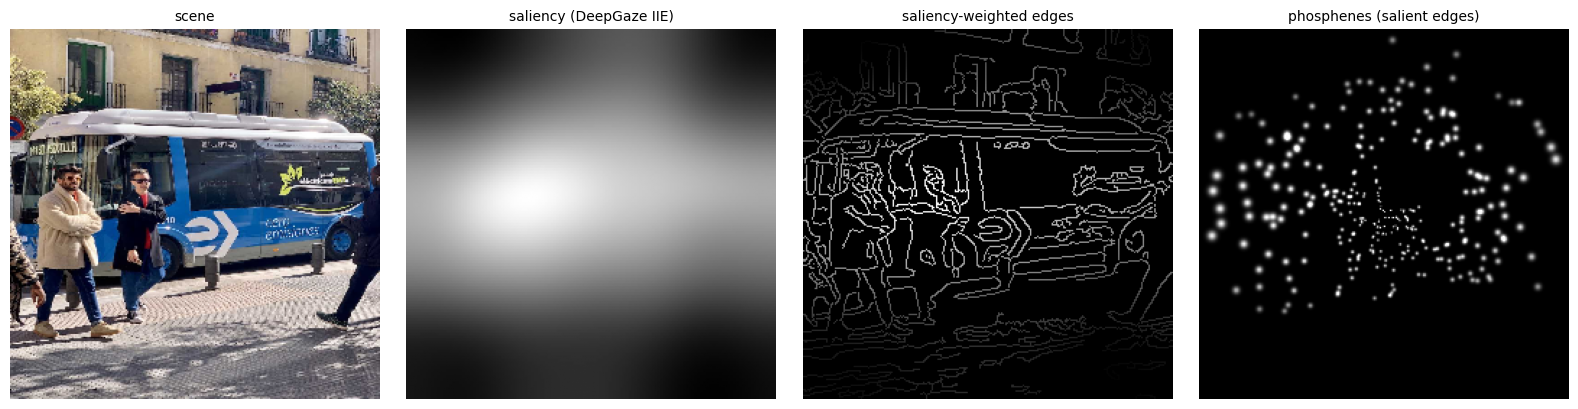

In [ ]:
saliency_src = 'DeepGaze IIE'
try:
    import deepgaze_pytorch
    # DeepGaze IIE is a backbone *ensemble* (~0.8 GB of weights); on a 4 GB GPU
    # already holding YOLO + MiDaS it can run out of memory, so fall back to CPU.
    dg_device = DEVICE
    try:
        dgmodel = deepgaze_pytorch.DeepGazeIIE(pretrained=True).to(dg_device).eval()
    except RuntimeError:
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        dg_device = 'cpu'
        dgmodel = deepgaze_pytorch.DeepGazeIIE(pretrained=True).to(dg_device).eval()

    rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)
    img_t = torch.tensor(rgb.transpose(2, 0, 1)[None].astype('float32')).to(dg_device)
    centerbias = torch.zeros((1,) + RES[::-1], dtype=torch.float32, device=dg_device)  # uniform prior
    with torch.no_grad():
        logdensity = dgmodel(img_t, centerbias).squeeze().cpu().numpy()   # (H, W) log-density
    del dgmodel
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print(f'DeepGaze IIE ran on {dg_device}.')
except Exception as e:
    print('DeepGaze unavailable, falling back to spectral-residual saliency:', e)
    saliency_src = 'spectral-residual (fallback)'
    if hasattr(cv2, 'saliency'):
        _, sm = cv2.saliency.StaticSaliencySpectralResidual_create().computeSaliency(scene_bgr)
        logdensity = sm.astype('float32')
    else:
        g = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2GRAY).astype('float32') / 255.0
        F = np.fft.fft2(g); logamp = np.log(np.abs(F) + 1e-9)
        sr = logamp - cv2.boxFilter(logamp, -1, (3, 3))
        logdensity = cv2.GaussianBlur(np.abs(np.fft.ifft2(np.exp(sr + 1j*np.angle(F))))**2, (9, 9), 2.5)

# Saliency as a [0, 1] weight map.
sal = cv2.resize(logdensity.astype('float32'), RES)
sal = (sal - sal.min()) / (np.ptp(sal) + 1e-9)

# Edges carry the legible structure; saliency decides which edges matter. Set
# each edge pixel's brightness to the local saliency, so edges in salient
# regions stay bright while edges in ignored regions dim out. We feed this at
# STIM_GAIN *without* stim_normalize: the firing threshold then does the
# filtering — edges below ~30% saliency fall under threshold and simply vanish,
# the rest fire with saliency-graded brightness.
edges = cv2.Canny(cv2.GaussianBlur(scene_gray, (5, 5), 1.4), 50, 150)
edge_saliency = ((edges > 0).astype(np.float32) * sal * 255).astype(np.uint8)

show(scene_bgr, (sal * 255).astype(np.uint8), edge_saliency,
     render(edge_saliency, gain=STIM_GAIN),
     titles=['scene', f'saliency ({saliency_src})', 'saliency-weighted edges',
             'phosphenes (salient edges)'],
     cols=4, figsize=(16, 4))

### Exercise 4.4 — open-vocabulary prompts `[challenge]`

YOLOv8 sees only the 80 COCO classes. **YOLO-World** accepts a free-text
class list and finds whatever you ask for — "stop sign", "crosswalk",
"door". The challenge is authoring the class list so the resulting
phosphene render is **legible**: pick few large objects, not many small
ones.

```python
from ultralytics import YOLO
ovw = YOLO('yolov8s-world.pt')                              # downloads ~50 MB on first run
ovw.set_classes(['bus', 'person', 'door'])
ov_res = ovw.predict(str(BUS), device=DEVICE, verbose=False)[0]
```

1. Get the boxes from `ov_res.boxes.xyxy.cpu().numpy()`. (YOLO-World
   gives bounding boxes; for segmentation masks you'd swap in
   `yoloe-11s-seg.pt`.)
2. Build a binary mask: for each box, paint a filled rectangle of 255
   into a zeros canvas of shape `RES[::-1]`.
3. Render and display.

Try a few class lists. What happens to the render as you add more, smaller objects?


In [ ]:
ov_ok = False
try:
    from ultralytics import YOLO
    ovw = YOLO('yolov8s-world.pt')
    ovw.set_classes(['bus', 'person', 'door'])
    ov_res = ovw.predict(str(BUS), device=DEVICE, verbose=False)[0]
    ov_ok = True
    print(f'YOLO-World ran on {DEVICE}. {len(ov_res.boxes)} detections for the prompt list.')
except Exception as e:
    print('YOLO-World unavailable, reusing YOLO seg as a stand-in:', e)

if ov_ok:
    h_in, w_in = bgr.shape[:2]
    sx, sy = RES[0]/w_in, RES[1]/h_in
    canvas = np.zeros(RES[::-1], dtype=np.uint8)
    for x1, y1, x2, y2 in ov_res.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = int(x1*sx), int(y1*sy), int(x2*sx), int(y2*sy)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), 255, -1)
else:
    canvas = (np.any(masks.astype(bool), axis=0).astype(np.uint8) * 255)

show(scene_bgr, canvas, render(stim_normalize(canvas), gain=STIM_GAIN),
     titles=['scene', 'open-vocab boxes' if ov_ok else 'YOLO union (fallback)',
             'phosphenes from open-vocab'],
     cols=3, figsize=(12, 4))

YOLO-World unavailable, reusing YOLO seg as a stand-in: name 'BUS' is not defined


NameError: name 'np' is not defined

## 5 · Dynamic stimulus loop

So far §3 watched what one electrode does over time *with a constant
stimulus*, and §4 watched what happens with *one image*. The real world
has both at once: the camera moves, objects move, and adaptation
accumulates while the content underneath the electrodes changes.

The interactive HTML page added a "drifting image" loop after round-2
feedback to make this visible. The challenge below is the Python
equivalent.


### Exercise 5.1 — pan a scene through the simulator `[challenge]`

Take any §4 stimulus (the YOLO union is the simplest), pan it
horizontally by 2 px per frame for 60 frames, and run the *same*
simulator across the sequence **without** resetting between frames.

1. Pick a stimulus image, e.g. `stim = union.copy()` (uint8, shape `RES[::-1]`).
2. Build a `frames` list. For each `t` in `range(60)`:
   * `shifted = np.roll(stim, shift=t*2, axis=1)`
   * `amp = sim.sample_stimulus(shifted, rescale=True)`
   * `phos = sim(amp)` — **do not** call `sim.reset()` inside the loop
   * append `phos.detach().cpu().numpy()` to `frames`
3. Display every 10th frame in a row, plus a brightness-over-time plot.

Compare to a reset-every-frame run (call `sim.reset()` inside the loop).
Which is more faithful to a real implant?


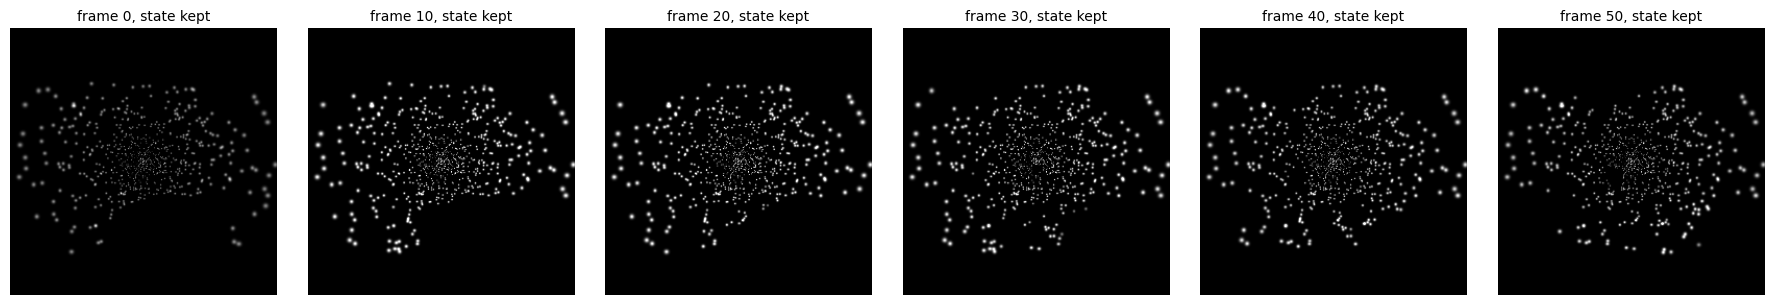

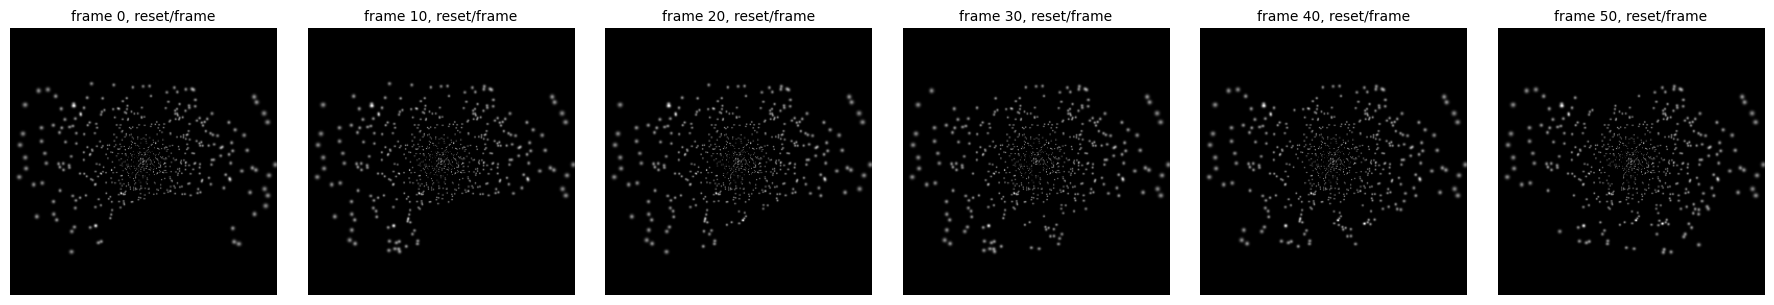

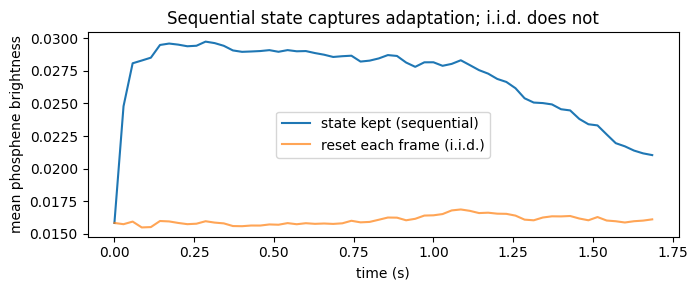

In [ ]:
def run_pan(reset_each_frame: bool):
    sim.reset()
    frames, bright = [], []
    stim = union.copy()
    for t in range(60):
        if reset_each_frame:
            sim.reset()
        shifted = np.roll(stim, shift=t*2, axis=1)
        amp = sim.sample_stimulus(shifted, rescale=True)
        phos = sim(amp)
        frames.append(phos.detach().cpu().numpy())
        bright.append(float(phos.detach().mean()))
    return frames, np.array(bright)

frames_seq, b_seq   = run_pan(reset_each_frame=False)
frames_iid, b_iid   = run_pan(reset_each_frame=True)

picks = [0, 10, 20, 30, 40, 50]
show(*[frames_seq[i] for i in picks],
     titles=[f'frame {i}, state kept' for i in picks], cols=6, figsize=(18, 3))
show(*[frames_iid[i] for i in picks],
     titles=[f'frame {i}, reset/frame' for i in picks], cols=6, figsize=(18, 3))

t = np.arange(60) / params['run']['fps']
plt.figure(figsize=(7, 3))
plt.plot(t, b_seq, label='state kept (sequential)')
plt.plot(t, b_iid, label='reset each frame (i.i.d.)', alpha=0.7)
plt.xlabel('time (s)'); plt.ylabel('mean phosphene brightness')
plt.title('Sequential state captures adaptation; i.i.d. does not')
plt.legend(); plt.tight_layout(); plt.show()


---

**Done.** You drove the same dynaphos simulator from five different
upstream representations (intensity, edges, YOLO masks, depth,
saliency, open-vocab boxes) and watched what each one looks like under
sequential temporal dynamics. Bring whichever stimulus path you found
most legible into M5 — it becomes the input to the decoding-and-closed-
loop module.

Module lead: Lefteris & Jorge. Edit this notebook directly; commit your
additions to the bootcamp repo at the end of the day.
